In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [14]:
df = sns.load_dataset("titanic")

In [15]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
df.shape

(891, 15)

In [18]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [19]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [20]:
df.duplicated().sum()

np.int64(107)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,784.000000,784.000000,678.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,29.869351,0.522959,0.415816,34.711740
std,0.492507,0.855056,14.759076,0.986231,0.836922,52.160151
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.250000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,39.000000,1.000000,1.000000,34.109350
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Data preparation:

In [23]:
def age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age <= 12:
        return "Child"
    elif age <= 19:
        return "Teen"
    elif age <= 59:
        return "Adult"
    else:
        return "Senior"

df['AgeGroup'] = df['age'].apply(age_group)

In [24]:
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

def family_group(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"

df['FamilyGroup'] = df['FamilySize'].apply(family_group)

KPI REQUIREMENTS:

1. Total Passengers

In [25]:
total_passengers = len(df)
print("Total Passengers:", total_passengers)

Total Passengers: 784


2. Total Survivors

In [26]:
total_survivors = df['survived'].sum()
print("Total Survivors:", total_survivors)

Total Survivors: 323


3. Total Non-Survivors

In [27]:
total_non_survivors = total_passengers - total_survivors
print("Total Non-Survivors:", total_non_survivors)

Total Non-Survivors: 461


4. Overall Survival Rate

In [28]:
overall_survival_rate = round((total_survivors / total_passengers) * 100, 2)
print("Overall Survival Rate:", overall_survival_rate)

Overall Survival Rate: 41.2


DEMOGRAPHIC KPIs

5. Survival Rate by Gender

In [29]:
gender_kpi = df.groupby('sex')['survived'].mean() * 100

male_survival = round(gender_kpi['male'],2)
female_survival = round(gender_kpi['female'],2)

print("Male Survival %:", male_survival)
print("Female Survival %:", female_survival)

Male Survival %: 21.59
Female Survival %: 74.06


6. Survival Rate by Age Group

In [30]:
age_kpi = df.groupby('AgeGroup')['survived'].mean() * 100
print(age_kpi.round(2))

AgeGroup
Adult      40.28
Child      57.35
Senior     26.92
Teen       43.33
Unknown    36.79
Name: survived, dtype: float64


SOCIOECONOMIC KPIs

7. Survival Rate by Passenger Class

In [31]:
class_kpi = df.groupby('pclass')['survived'].mean() * 100
print(class_kpi.round(2))

pclass
1    63.08
2    50.91
3    25.68
Name: survived, dtype: float64


8. Average Fare Paid

In [32]:
fare_kpi = df.groupby('survived')['fare'].mean().round(2)
print("Avg Fare Non-Survivors:", fare_kpi[0])
print("Avg Fare Survivors:", fare_kpi[1])

Avg Fare Non-Survivors: 23.94
Avg Fare Survivors: 50.08


OPERATIONAL KPIs

9. Survival Rate by Embarkation Port

In [33]:
embark_kpi = df.groupby('embarked')['survived'].mean() * 100
print(embark_kpi.round(2))

embarked
C    58.06
Q    33.90
S    37.15
Name: survived, dtype: float64


10. Family Size Impact

In [34]:
family_kpi = df.groupby('FamilyGroup')['survived'].mean() * 100
print(family_kpi.round(2))

FamilyGroup
Alone           33.63
Large Family    18.18
Small Family    57.60
Name: survived, dtype: float64


CHART REQUIREMENTS

1. Survival Distribution

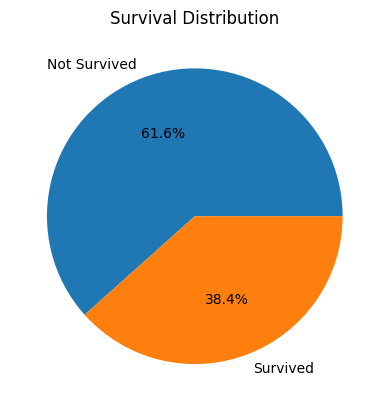

In [44]:
survival_counts = df['survived'].value_counts()

plt.pie(survival_counts, labels=['Not Survived','Survived'], autopct='%1.1f%%')
plt.title("Survival Distribution")
plt.show()

2. Survival by Gender

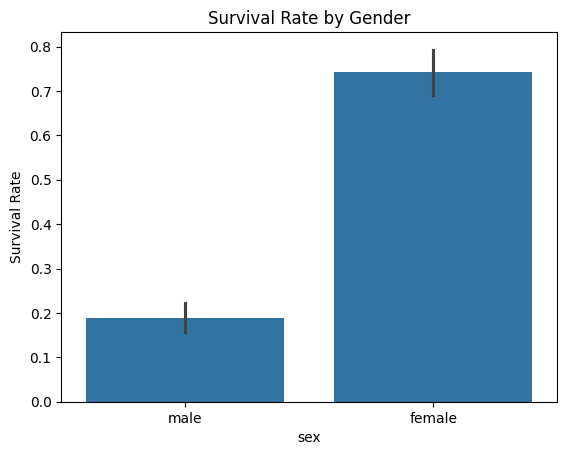

In [45]:
sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

3. Survival by Passenger Class

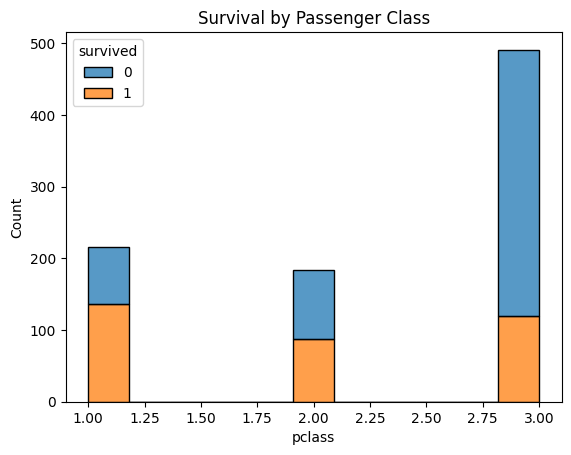

In [46]:
sns.histplot(data=df, x='pclass', hue='survived', multiple='stack')
plt.title("Survival by Passenger Class")
plt.show()

4. Age Distribution by Survival

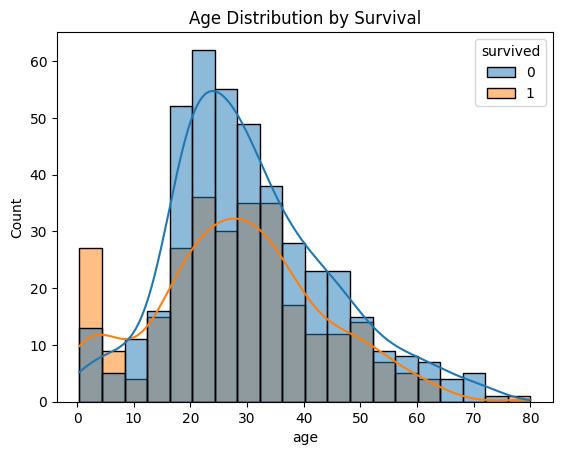

In [47]:
sns.histplot(data=df, x='age', hue='survived', kde=True)
plt.title("Age Distribution by Survival")
plt.show()

5. Fare vs Survival

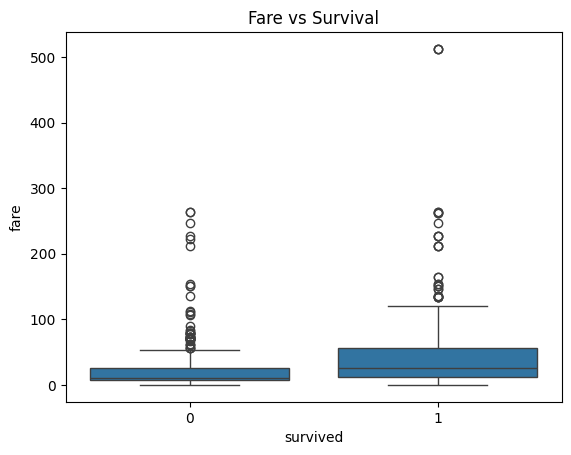

In [48]:
sns.boxplot(x='survived', y='fare', data=df)
plt.title("Fare vs Survival")
plt.show()

6. Survival by Embarkation Port

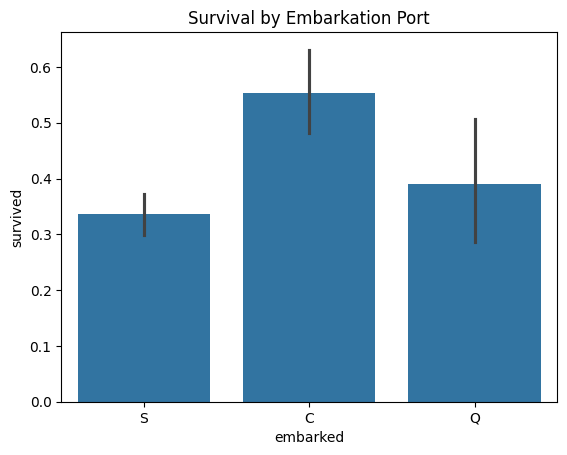

In [49]:
sns.barplot(x='embarked', y='survived', data=df)
plt.title("Survival by Embarkation Port")
plt.show()

7. Family Size Impact

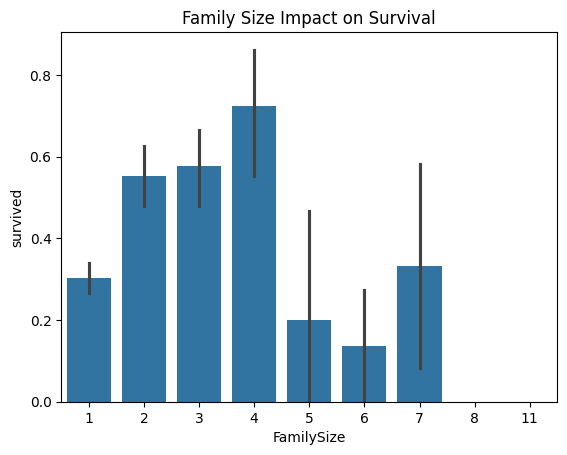

In [50]:
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

sns.barplot(x='FamilySize', y='survived', data=df)
plt.title("Family Size Impact on Survival")
plt.show()

1. What was the overall survival rate?

The overall survival rate was around 38%, indicating that most passengers did not survive the disaster.

2. Did gender influence survival probability?

Yes, females had a significantly higher survival rate than males, showing strong gender-based survival priority.

3. Did passenger class affect survival?

 Yes, 1st class passengers had the highest survival rate, while 3rd class had the lowest, indicating socioeconomic advantage.

4. Were children more likely to survive?

Yes, children had better survival chances than adults, supporting the “women and children first” policy.

5. Did fare correlate with survival?

Yes, passengers who paid higher fares were more likely to survive, suggesting wealth influenced access to safety.

6. Did embarkation port impact survival?

Yes, passengers from Cherbourg showed higher survival rates, likely due to a higher proportion of upper-class travelers.

Static dashboard:

In [42]:
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load Data
df = sns.load_dataset("titanic")

# Create Age Group
def age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age <= 12:
        return "Child"
    elif age <= 19:
        return "Teen"
    elif age <= 59:
        return "Adult"
    else:
        return "Senior"

df['AgeGroup'] = df['age'].apply(age_group)

# Create Family Size
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

def family_group(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"

df['FamilyGroup'] = df['FamilySize'].apply(family_group)

# KPIs
total_passengers = len(df)
total_survivors = df['survived'].sum()
total_non_survivors = total_passengers - total_survivors
survival_rate = round((total_survivors / total_passengers) * 100,2)

male_survival = round(df[df['sex']=="male"]['survived'].mean()*100,2)
female_survival = round(df[df['sex']=="female"]['survived'].mean()*100,2)

# Create Dashboard
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=(
        "Survival Distribution",
        "Survival by Gender",
        "Survival by Class",
        "Age Distribution",
        "Fare vs Survival",
        "Survival by Embarkation",
        "Family Size Impact"
    ),
    specs=[
        [{"type":"domain"}, {"type":"xy"}, {"type":"xy"}],
        [{"type":"xy"}, {"type":"xy"}, {"type":"xy"}],
        [{"type":"xy"}, None, None]
    ]
)

# 1 Survival Distribution
survival_counts = df['survived'].value_counts()
fig.add_trace(go.Pie(labels=['Not Survived','Survived'],
                     values=survival_counts,
                     hole=0.4),
              row=1, col=1)

# 2 Survival by Gender
gender_survival = df.groupby('sex')['survived'].mean().reset_index()
fig.add_trace(go.Bar(x=gender_survival['sex'],
                     y=gender_survival['survived']),
              row=1, col=2)

# 3 Survival by Class
class_survival = df.groupby('pclass')['survived'].mean().reset_index()
fig.add_trace(go.Bar(x=class_survival['pclass'],
                     y=class_survival['survived']),
              row=1, col=3)

# 4 Age Distribution
fig.add_trace(go.Histogram(x=df['age']),
              row=2, col=1)

# 5 Fare vs Survival
fig.add_trace(go.Box(x=df['survived'],
                     y=df['fare']),
              row=2, col=2)

# 6 Survival by Embarkation
embark_survival = df.groupby('embarked')['survived'].mean().reset_index()
fig.add_trace(go.Bar(x=embark_survival['embarked'],
                     y=embark_survival['survived']),
              row=2, col=3)

# 7 Family Size Impact
family_survival = df.groupby('FamilyGroup')['survived'].mean().reset_index()
fig.add_trace(go.Bar(x=family_survival['FamilyGroup'],
                     y=family_survival['survived']),
              row=3, col=1)

# Dashboard Title with KPIs
fig.update_layout(
    title_text=f"""
    TITANIC SURVIVAL DASHBOARD

    Total Passengers: {total_passengers}
    Total Survivors: {total_survivors}
    Total Non-Survivors: {total_non_survivors}
    Survival Rate: {survival_rate}%
    Male Survival: {male_survival}%
    Female Survival: {female_survival}%
    """,
    height=900,
    showlegend=False
)

fig.show()